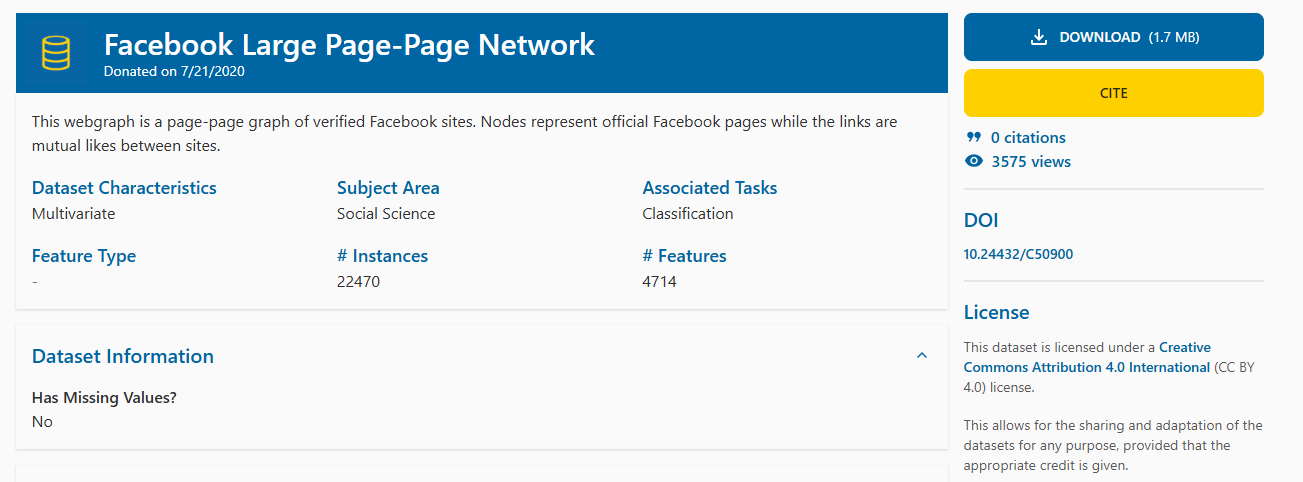

In [20]:
# %cd /content/drive/MyDrive/COMP3710
# !wget https://archive.ics.uci.edu/static/public/527/facebook+large+page+page+network.zip
# !unzip facebook+large+page+page+network.zip

'''
/content/drive/MyDrive/COMP3710
--2026-10-04 11:41:10--  https://archive.ics.uci.edu/static/public/527/facebook+large+page+page+network.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘facebook+large+page+page+network.zip.1’

facebook+large+page     [ <=>                ]   1.66M  --.-KB/s    in 0.09s

2026-10-04 11:41:10 (17.5 MB/s) - ‘facebook+large+page+page+network.zip.1’ saved [1737479]

Archive:  facebook+large+page+page+network.zip
   creating: facebook_large/
  inflating: facebook_large/musae_facebook_edges.csv
  inflating: facebook_large/musae_facebook_features.json
  inflating: facebook_large/musae_facebook_target.csv
  inflating: facebook_large/citing.txt'''

%cd /content/drive/MyDrive/COMP3710

/content/drive/MyDrive/COMP3710


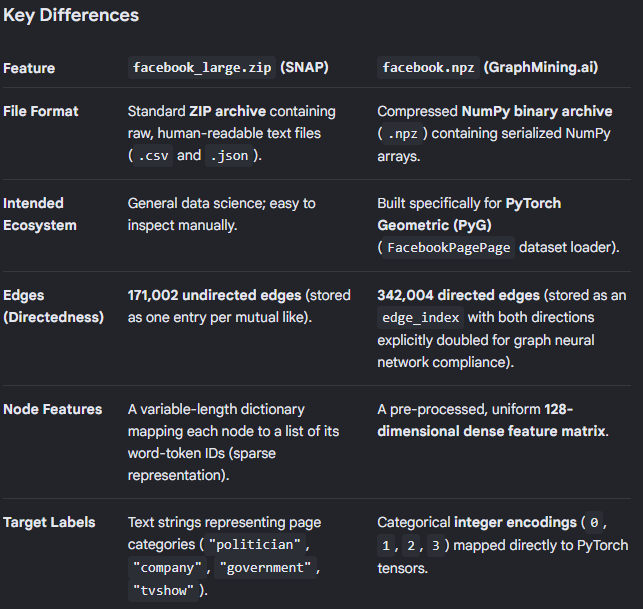

There are exactly 4,714 different token IDs (numbered 0 to 4713) in the musae_facebook_features.json dictionary.
Each token ID corresponds to a specific unique word extracted from the descriptions of the verified Facebook pages. If you were to convert this variable-length dictionary into a traditional one-hot encoded matrix for machine learning, it would result in a feature width of 4,714 columns.

In [22]:
import os
import zipfile
import json
import numpy as np
import pandas as pd
from sklearn.decomposition import TruncatedSVD

extract_dir = 'facebook_large'


# Define internal file paths
edges_csv = os.path.join(extract_dir, "musae_facebook_edges.csv")
target_csv = os.path.join(extract_dir, "musae_facebook_target.csv")
features_json = os.path.join(extract_dir, "musae_facebook_features.json")

# --- 2. Process Node Features via SVD ---
print("Processing node features...")
with open(features_json, 'r') as f:
    features_dict = json.load(f)

num_nodes = len(features_dict)
num_features = 4714  # Exact unique token ID count

# Construct a sparse binary matrix
X_sparse = np.zeros((num_nodes, num_features), dtype=np.float32)
for node, tokens in features_dict.items():
    X_sparse[int(node), tokens] = 1.0

# Apply dimensionality reduction down to 128 dimensions (as per MUSAE paper)
svd = TruncatedSVD(n_components=128, random_state=42)
X_dense = svd.fit_transform(X_sparse)

# --- 3. Process Edges (Double them for PyG undirected representation) ---
print("Processing edges...")
edges_df = pd.read_csv(edges_csv)
src = edges_df['id_1'].values
dst = edges_df['id_2'].values

# PyG expects both directions explicitly defined for undirected graphs
edge_index_x = np.concatenate([src, dst])
edge_index_y = np.concatenate([dst, src])

# --- 4. Process Target Labels ---
print("Processing target labels...")
target_df = pd.read_csv(target_csv)
# Sort by node ID to ensure aligned order
target_df = target_df.sort_values(by='id').reset_index(drop=True)

# GraphMining maps categorical string classes to integers
# "tvshow" -> 0, "government" -> 1, "company" -> 2, "politician" -> 3
y_labels = target_df['page_type'].astype('category').cat.codes.values
y_page_names = target_df['page_name'].astype('str').values

# --- 5. Save exactly as GraphMining.ai's format ---
print("Saving to facebook.npz...")
np.savez_compressed(
    "facebook.npz",
    X=X_dense,
    edges_x=edge_index_x,
    edges_y=edge_index_y,
    y=y_labels,
    page_name=y_page_names
)

print("Conversion complete! Output file: facebook.npz")

Processing node features...
Processing edges...
Processing target labels...
Saving to facebook.npz...
Conversion complete! Output file: facebook.npz


In [25]:
data = np.load("facebook.npz", allow_pickle=True)
print(data['X'].shape)        # Output: (22470, 128)
print(data['edges_x'].shape)  # Output: (342004,)
print(data['edges_y'].shape)  # Output: (342004,)
print(data['y'].shape)        # Output: (22470,)
print(data['page_name'][1])

(22470, 128)
(342004,)
(342004,)
(22470,)
U.S. Consulate General Mumbai
